In [1]:
# Run garbage collection
import gc
gc.collect()

0

In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import logging
import wfdb
import ast
import torch
import seaborn as sns
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_score, recall_score, confusion_matrix
from tabulate import tabulate
import os
from collections import Counter
from scipy.signal import spectrogram

In [3]:
path_load = 'data_source'

X_train = np.load(os.path.join(path_load, 'data_sourceY_train.npy'))
y_train = pd.read_csv(os.path.join(path_load, 'data_sourceZ_train.csv'))
y_train = y_train.drop(columns=['ecg_id'])

X_test = np.load(os.path.join(path_load, 'data_sourceY_test.npy'))
y_test = pd.read_csv(os.path.join(path_load, 'data_sourceZ_test.csv'))
y_test = y_test.drop(columns=['ecg_id'])

X_val = np.load(os.path.join(path_load, 'data_sourceY_valid.npy'))
y_val = pd.read_csv(os.path.join(path_load, 'data_sourceZ_valid.csv'))
y_val = y_val.drop(columns=['ecg_id'])

table = [
    ["X_train", X_train.shape],
    ["y_train", y_train.shape],
    ["X_test", X_test.shape],
    ["y_test", y_test.shape],
    ["X_val", X_val.shape],
    ["y_val", y_val.shape],
]

print(tabulate(table, headers=["Dataset", "Shape"], tablefmt="grid"))

+-----------+-------------------+
| Dataset   | Shape             |
+===========+===================+
| X_train   | (17418, 1000, 12) |
+-----------+-------------------+
| y_train   | (17418, 5)        |
+-----------+-------------------+
| X_test    | (2198, 1000, 12)  |
+-----------+-------------------+
| y_test    | (2198, 5)         |
+-----------+-------------------+
| X_val     | (2183, 1000, 12)  |
+-----------+-------------------+
| y_val     | (2183, 5)         |
+-----------+-------------------+


In [4]:
label_map = {
    0: "NORM",
    1: "MI",
    2: "STTC",
    3: "CD",
    4: "HYP",
}
label_indices = {label: y_train.index[y_train[label] == 1].tolist() for label in y_train.columns}

print("Label indices:")
for label, indices in label_indices.items():
    print(f"{label}: {indices[:10]}... (total {len(indices)})")

Label indices:
NORM: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]... (total 7596)
MI: [31, 48, 69, 72, 87, 92, 101, 109, 111, 112]... (total 4379)
STTC: [15, 34, 57, 68, 88, 89, 92, 94, 103, 105]... (total 4186)
CD: [21, 29, 31, 32, 48, 57, 68, 69, 97, 106]... (total 3907)
HYP: [29, 63, 72, 91, 92, 117, 122, 128, 135, 173]... (total 2119)


Processing label: NORM


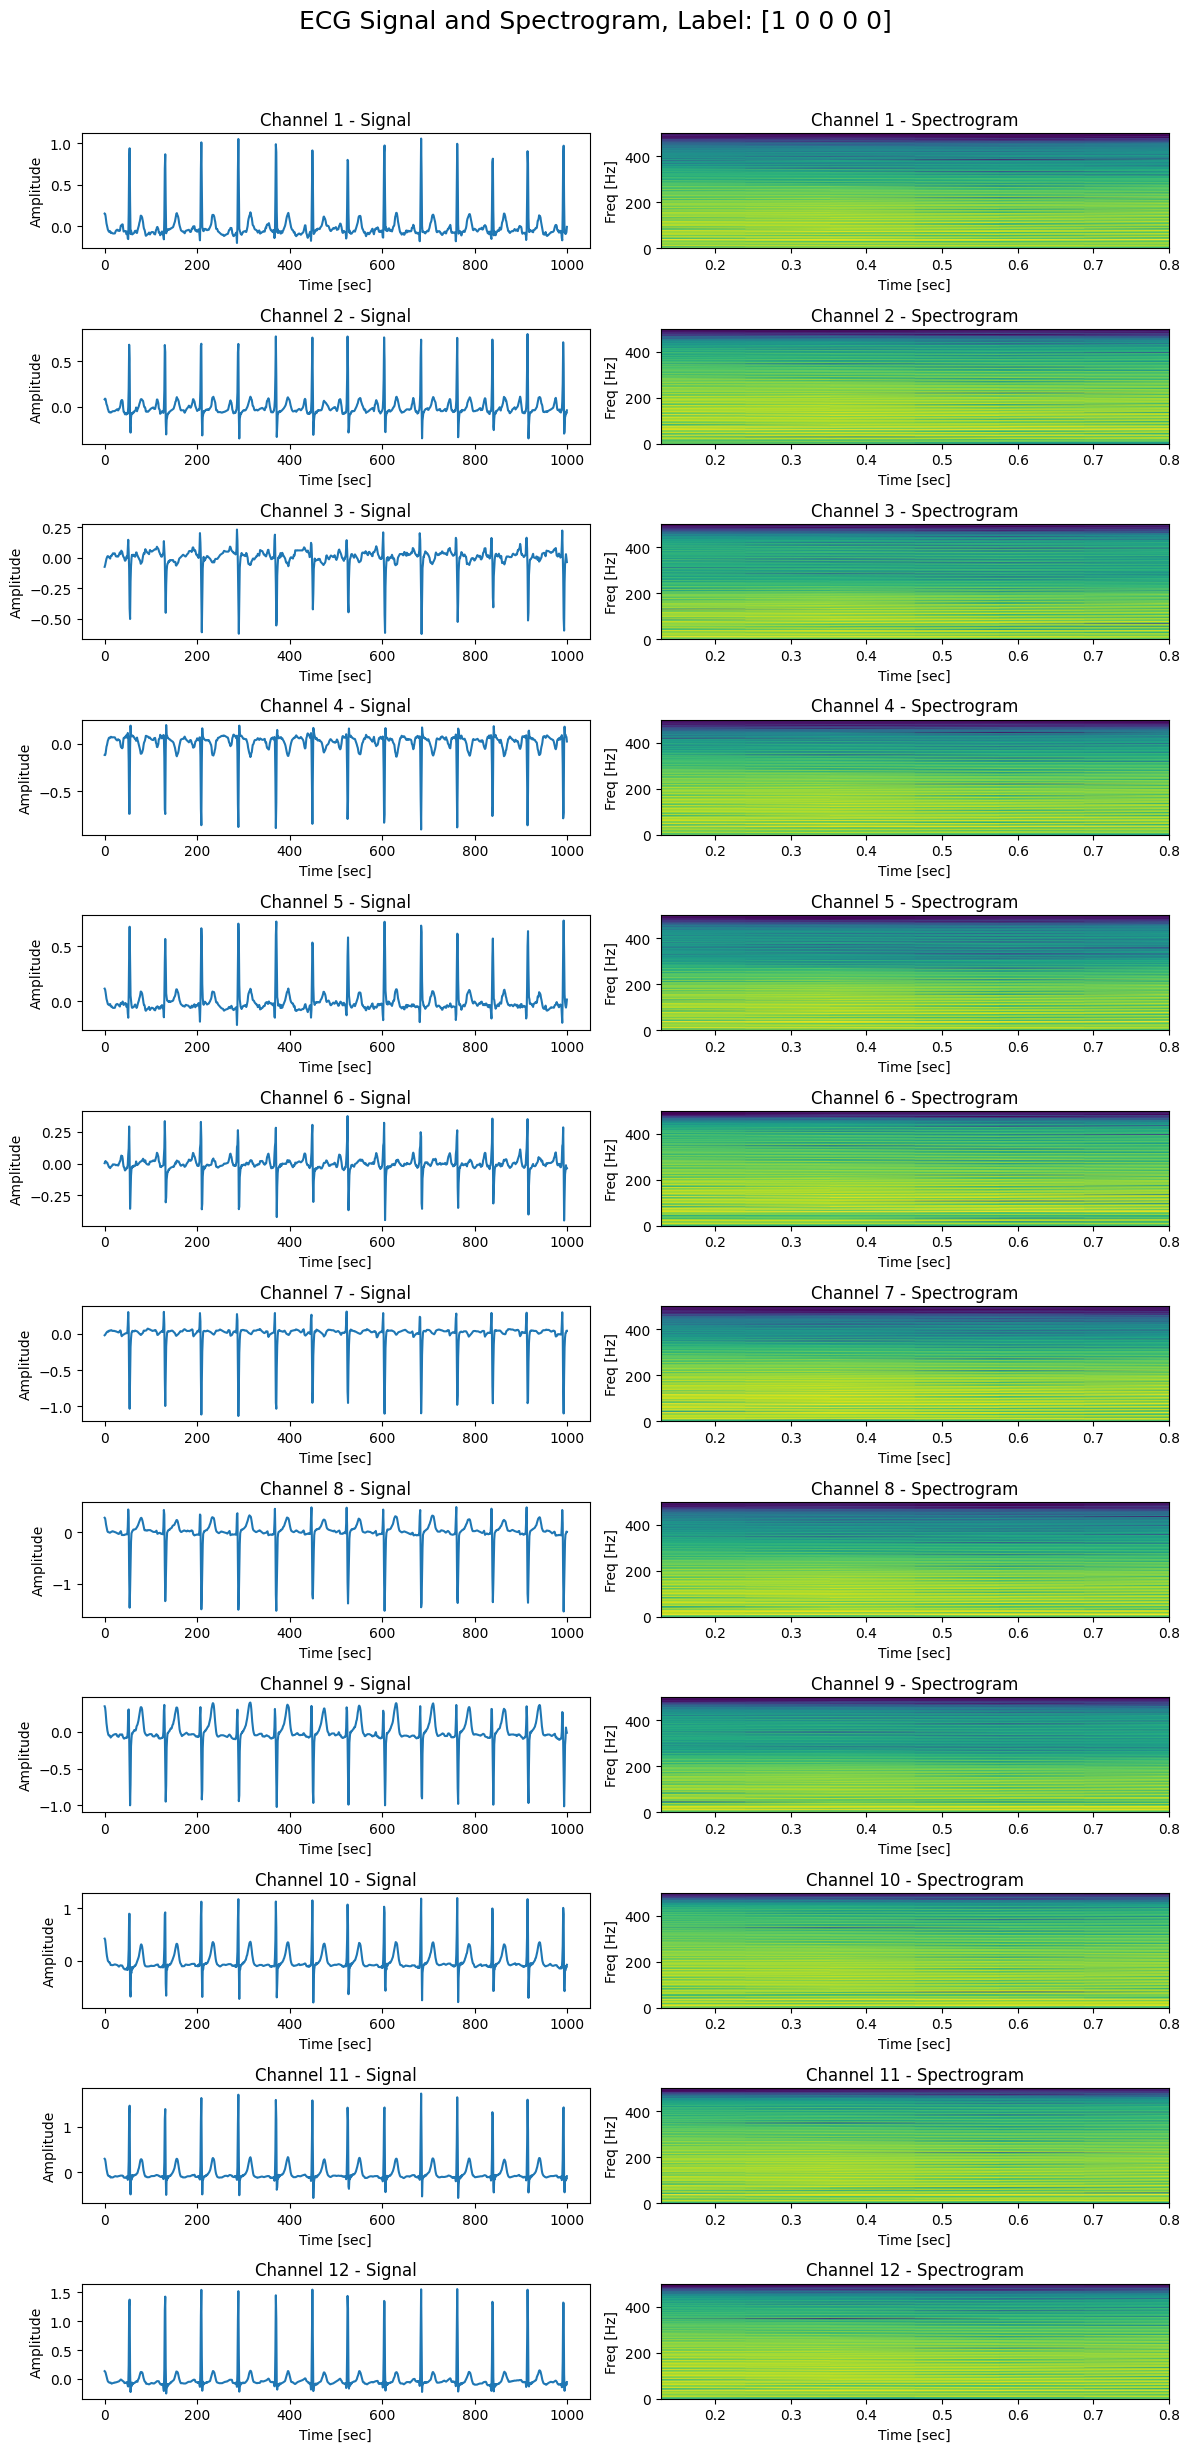

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import spectrogram
import random
fs = 1000
random.seed(42)  # Set your seed for reproducibility

for i in range(len(label_map)):
    print(f"Processing label: {label_map[i]}")
    random_index = random.choice(label_indices[label_map[i]])
    data = X_train[random_index]
    label = y_train[y_train.index == random_index].values[0]
    fig, axes = plt.subplots(12, 2, figsize=(12, 24))

    for ch in range(12):
        # Plot time-domain signal
        signal = data[:, ch]
        axes[ch, 0].plot(signal)
        axes[ch, 0].set_title(f'Channel {ch+1} - Signal')
        axes[ch, 0].set_ylabel('Amplitude')
        axes[ch, 0].set_xlabel('Time [sec]')
    
        # Plot spectrogram
        f, t_spec, Sxx = spectrogram(signal, fs)
        pcm = axes[ch, 1].pcolormesh(t_spec, f, 10 * np.log10(Sxx + 1e-10), shading='gouraud', cmap='viridis')
        axes[ch, 1].set_title(f'Channel {ch+1} - Spectrogram')
        axes[ch, 1].set_ylabel('Freq [Hz]')
        axes[ch, 1].set_xlabel('Time [sec]')
        axes[ch, 1].set_ylim(0, 500)  # Limit to 100 Hz for ECG
    
    plt.suptitle(f"ECG Signal and Spectrogram, Label: {label}", fontsize=18, y=1.02)
    plt.tight_layout()
    plt.show()
    break

In [5]:
fs = 1000
for ch in range(12):
        # Plot time-domain signal
        signal = data[:, ch]
        axes[ch, 0].plot(signal)
        axes[ch, 0].set_title(f'Channel {ch+1} - Signal')
        axes[ch, 0].set_ylabel('Amplitude')
        axes[ch, 0].set_xlabel('Time [sec]')
    
        # Plot spectrogram
        f, t_spec, Sxx = spectrogram(signal, fs)
        pcm = axes[ch, 1].pcolormesh(t_spec, f, 10 * np.log10(Sxx + 1e-10), shading='gouraud', cmap='viridis')
        axes[ch, 1].set_title(f'Channel {ch+1} - Spectrogram')
        axes[ch, 1].set_ylabel('Freq [Hz]')
        axes[ch, 1].set_xlabel('Time [sec]')
        axes[ch, 1].set_ylim(0, 500)  # Limit to 100 Hz for ECG
    
plt.suptitle(f"ECG Signal and Spectrogram, Label: {label}", fontsize=18, y=1.02)
plt.tight_layout()
plt.show()

NameError: name 'data' is not defined

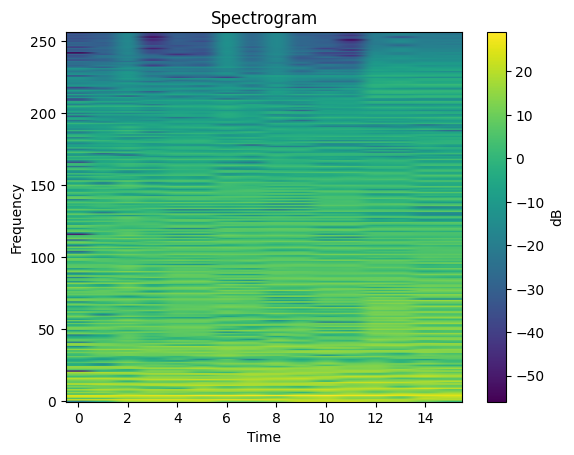

In [7]:
import torch
random_index = 1
data = X_train[random_index]
signal = data[:, 0]
signal = torch.from_numpy(signal)
spec = torch.stft(signal, n_fft=512, hop_length=64, win_length=512, return_complex=True)
magnitude = spec.abs()  # [freq, time]
# Optional: Convert to dB scale
magnitude_db = 20 * torch.log10(magnitude + 1e-6)

# Plot
plt.imshow(magnitude_db.numpy(), aspect='auto', origin='lower', cmap='viridis')
plt.title("Spectrogram")
plt.xlabel("Time")
plt.ylabel("Frequency")
plt.colorbar(label="dB")
plt.show()

In [7]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import wfdb
import ast
import torch
import seaborn as sns
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_score, recall_score, confusion_matrix
from tabulate import tabulate
import os
from collections import Counter
from sklearn.preprocessing import StandardScaler
import torchaudio.transforms as T

In [ ]:
def normalize_data_z_score(data: np.ndarray) -> np.ndarray:
    num_samples, sample_length, num_channels = data.shape
    data_reshaped = data.reshape(-1, num_channels)
    scaler = StandardScaler()
    data_normalized = scaler.fit_transform(data_reshaped)
    return data_normalized.reshape(num_samples, sample_length, num_channels)

In [ ]:
path_load = 'data_source'

X_train = np.load(os.path.join(path_load, 'data_sourceY_train.npy'))
X_train = normalize_data_z_score(X_train)

y_train = pd.read_csv(os.path.join(path_load, 'data_sourceZ_train.csv'))
y_train = y_train.drop(columns=['ecg_id'])
y_train = y_train.to_numpy(dtype=np.float32)

X_test = np.load(os.path.join(path_load, 'data_sourceY_test.npy'))
X_test = normalize_data_z_score(X_test)

y_test = pd.read_csv(os.path.join(path_load, 'data_sourceZ_test.csv'))
y_test = y_test.drop(columns=['ecg_id'])
y_test = y_test.to_numpy(dtype=np.float32)

X_val = np.load(os.path.join(path_load, 'data_sourceY_valid.npy'))
X_val = normalize_data_z_score(X_val)

y_val = pd.read_csv(os.path.join(path_load, 'data_sourceZ_valid.csv'))
y_val = y_val.drop(columns=['ecg_id'])
y_val = y_val.to_numpy(dtype=np.float32)

table = [
    ["X_train", X_train.shape],
    ["y_train", y_train.shape],
    ["X_test", X_test.shape],
    ["y_test", y_test.shape],
    ["X_val", X_val.shape],
    ["y_val", y_val.shape],
]

print(tabulate(table, headers=["Dataset", "Shape"], tablefmt="grid"))

+-----------+-------------------+
| Dataset   | Shape             |
+===========+===================+
| X_train   | (17418, 1000, 12) |
+-----------+-------------------+
| y_train   | (17418, 5)        |
+-----------+-------------------+
| X_test    | (2198, 1000, 12)  |
+-----------+-------------------+
| y_test    | (2198, 5)         |
+-----------+-------------------+
| X_val     | (2183, 1000, 12)  |
+-----------+-------------------+
| y_val     | (2183, 5)         |
+-----------+-------------------+


In [8]:
x_train = torch.from_numpy(X_train).float()  # float tensor for input
labels_train = torch.from_numpy(y_train).float()  # float tensor for labels
x_val = torch.from_numpy(X_val).float()
labels_val = torch.from_numpy(y_val).float()
x_test = torch.from_numpy(X_test).float()
lables_test = torch.from_numpy(y_test).float()

batch_size = 32

train_dataset = TensorDataset(x_train, labels_train)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

val_dataset = TensorDataset(x_val, labels_val)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

test = TensorDataset(x_test, lables_test)
test_loader = DataLoader(test, batch_size=batch_size, shuffle=False)

In [ ]:
print((train_loader))

In [ ]:
ecg, labels = next(iter(train_loader))

print(f"Data shape: {ecg.shape}")
print(f"Labels shape: {labels.shape}")

ecg_permute = ecg.permute(0, 2, 1)
spec_transform = T.Spectrogram(n_fft=256, win_length=256, hop_length=64, power=2.0)
spec = spec_transform(ecg_permute)  # [B, C, Freq, Time]

Data shape: torch.Size([32, 1000, 12])
Labels shape: torch.Size([32, 5])


In [19]:
batch = next(iter(train_loader))
if isinstance(batch, (list)) and len(batch) == 2:
    x, y = batch
    print("Input shape:", x.shape)
    print("Target shape:", y.shape)
else:
    print("Batch structure:", type(batch), batch)

Input shape: torch.Size([32, 1000, 12])
Target shape: torch.Size([32, 5])


In [23]:
print(spec.shape)
print(spec[0,0].shape)

torch.Size([32, 12, 129, 16])
torch.Size([129, 16])


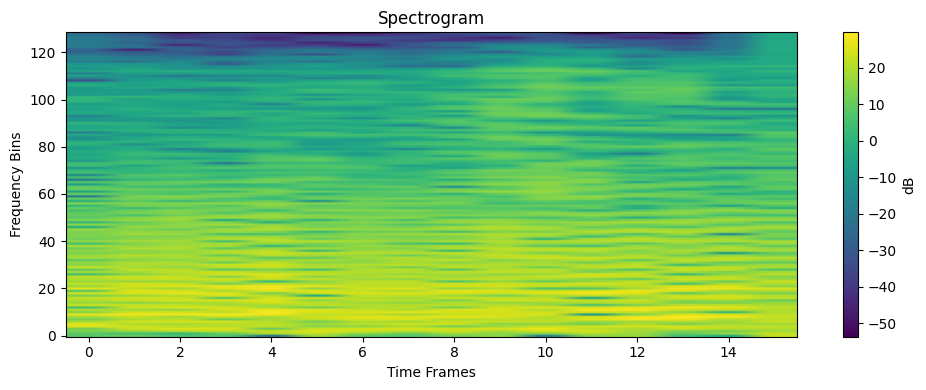

In [24]:
import matplotlib.pyplot as plt

# Pick first sample (index 0), first channel (index 0)
spec_sample = spec[0, 0]  # Shape: [Freq, Time]

# Optional: convert to dB (log scale) for better visualization
spec_db = 10 * torch.log10(spec_sample + 1e-6)

# Plot
plt.figure(figsize=(10, 4))
plt.imshow(spec_db.numpy(), aspect='auto', origin='lower', cmap='viridis')
plt.title("Spectrogram")
plt.xlabel("Time Frames")
plt.ylabel("Frequency Bins")
plt.colorbar(label='dB')
plt.tight_layout()
plt.show()